In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

DATASET LOAD

low_memory=False isliye ke cloudCover mein mixed types hain. Shape se pata chalta hai dataset kitna bada hai.

In [ ]:
df = pd.read_csv('HomeC.csv', low_memory=False)

print(f"✅ Dataset loaded.")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded.
   Shape: 503,911 rows × 32 columns


RAW DATA

Ye "Before" state hai — unix timestamp, mixed cloudCover, sab raw form mein.

In [ ]:
df.head()

,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


DATA INFO

Har column ka datatype aur null count — preprocessing ka blueprint.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503911 entries, 0 to 503910
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   time                 503911 non-null  object 
 1   use [kW]             503910 non-null  float64
 2   gen [kW]             503910 non-null  float64
 3   House overall [kW]   503910 non-null  float64
 4   Dishwasher [kW]      503910 non-null  float64
 5   Furnace 1 [kW]       503910 non-null  float64
 6   Furnace 2 [kW]       503910 non-null  float64
 7   Home office [kW]     503910 non-null  float64
 8   Fridge [kW]          503910 non-null  float64
 9   Wine cellar [kW]     503910 non-null  float64
 10  Garage door [kW]     503910 non-null  float64
 11  Kitchen 12 [kW]      503910 non-null  float64
 12  Kitchen 14 [kW]      503910 non-null  float64
 13  Kitchen 38 [kW]      503910 non-null  float64
 14  Barn [kW]            503910 non-null  float64
 15  Well [kW]        

MISSINGG VALUES

In [ ]:
missing = df.isnull().sum()                          # Count nulls per column
missing_pct = (missing / len(df) * 100).round(2)     # As a percentage

# Build a clean summary table — only show columns that HAVE missing values
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing %', ascending=False
)

if missing_df.empty:
    print("✅ No missing values found! Clean dataset.")
else:
    print(f"⚠️  {len(missing_df)} columns have missing values:\n")
    print(missing_df)
    print(f"\nTotal missing cells: {missing.sum():,} out of {df.size:,}")

⚠️  31 columns have missing values:

                     Missing Count  Missing %
use [kW]                         1        0.0
gen [kW]                         1        0.0
House overall [kW]               1        0.0
Dishwasher [kW]                  1        0.0
Furnace 1 [kW]                   1        0.0
Furnace 2 [kW]                   1        0.0
Home office [kW]                 1        0.0
Fridge [kW]                      1        0.0
Wine cellar [kW]                 1        0.0
Garage door [kW]                 1        0.0
Kitchen 12 [kW]                  1        0.0
Kitchen 14 [kW]                  1        0.0
Kitchen 38 [kW]                  1        0.0
Barn [kW]                        1        0.0
Well [kW]                        1        0.0
Microwave [kW]                   1        0.0
Living room [kW]                 1        0.0
Solar [kW]                       1        0.0
temperature                      1        0.0
icon                             1        0

CLOUDCOVER ISSUE

Yahan dikhega ke 'cloudCover' string bhi hai — ye corrupt header row hai beech mein.

In [ ]:
df['cloudCover'].unique()[:10]

array(['cloudCover', '0.75', '0', '1', '0.31', '0.44', '0.13', '0.19',
       '0.25', '0.16'], dtype=object)

TIME COLUMN

Unix timestamp dikhao — ugly numbers, human-readable nahi. Ye "before" proof hai.


In [ ]:
df['time'].head()

,time
0,1451624400
1,1451624401
2,1451624402
3,1451624403
4,1451624404


**PREPROCESSING **

Duplicate Header Row

Beech mein ek row thi jisme 'cloudCover' string thi — ye sensor bug thi. Hatana zaroori tha warna numeric conversion fail hoti.

In [ ]:
df = df[df['cloudCover'] != 'cloudCover']
df.shape

(503853, 32)

** CloudCover Ko Numeric Banao**


String tha, ML numbers chahta hai. errors='coerce' matlab jo convert na ho wo NaN ban jaye.


In [ ]:
df['cloudCover'] = pd.to_numeric(df['cloudCover'], errors='coerce')

**Duplicate Columns Remove**

House overall == use — same data tha, duplicate tha. Solar == gen — same tha. Redundant columns se model confuse hota hai.

In [ ]:
if 'House overall [kW]' in df.columns:
    match_house = (df['House overall [kW]'] == df['use [kW]']).mean()
    print(f"   'House overall [kW]' matches 'use [kW]': {match_house:.2%}")
    df = df.drop(columns=['House overall [kW]'])

if 'Solar [kW]' in df.columns:
    match_solar = (df['Solar [kW]'] == df['gen [kW]']).mean()
    print(f"   'Solar [kW]' matches 'gen [kW]': {match_solar:.2%}")
    df = df.drop(columns=['Solar [kW]'])

print(f"✅ Redundant columns removed. Shape: {df.shape}")

   'House overall [kW]' matches 'use [kW]': 100.00%
   'Solar [kW]' matches 'gen [kW]': 100.00%
✅ Redundant columns removed. Shape: (503853, 30)


**Feature Engineering (Appliances Merge)**

Teen kitchen sensors ek hi kitchen ke hain — merge karo. Do furnace sensors ek hi furnace ke hain — merge karo. Dimensionality reduce hoti hai, interpretation easy hoti hai.

In [ ]:
df['kitchen_total'] = df['Kitchen 12 [kW]'] + df['Kitchen 14 [kW]'] + df['Kitchen 38 [kW]']
df['furnace_total'] = df['Furnace 1 [kW]'] + df['Furnace 2 [kW]']

**Time Convert Karo + Time Features Nikalo**

Unix timestamp readable bana. Phir hour, month, day, weekend — ye sab energy consumption ke powerful predictors hain. Model timestamp nahi samajhta, features samajhta hai.

In [ ]:
# If 'time' is currently the index, reset it to make it a column again.
if 'time' in df.index.names:
    df.reset_index(inplace=True)

# Convert the 'time' column to datetime objects.
# 'errors='coerce'' will turn any values that cannot be parsed into NaT (Not a Time).
df['time'] = pd.to_datetime(df['time'], unit='s', errors='coerce')

# Drop any rows where the 'time' conversion resulted in NaT (meaning invalid time values).
df.dropna(subset=['time'], inplace=True)

# Extract time-based features from the now-valid 'time' column.
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['dayofweek'] = df['time'].dt.dayofweek           # 0=Mon, 6=Sun
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)  # 1=weekend

print("✅ Time features extracted: hour, month, day, dayofweek, is_weekend")
print(f"   Sample: hour={df['hour'].iloc[100]}, month={df['month'].iloc[100]}, "
      f"is_weekend={df['is_weekend'].iloc[100]}")

# Finally, set the 'time' column as the DataFrame's index.
df = df.set_index('time')
print(f"✅ 'time' set as index. Shape: {df.shape}")



/tmp/ipykernel_1008/498075921.py:7: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['time'] = pd.to_datetime(df['time'], unit='s', errors='coerce')


✅ Time features extracted: hour, month, day, dayofweek, is_weekend
   Sample: hour=5, month=1, is_weekend=0
✅ 'time' set as index. Shape: (503852, 36)


**FIX MISSING VALUES**

Median isliye kyunke energy data mein outliers hain — mean outliers se shift ho jata, median nahi hota.

In [ ]:
# Strategy: Median fill for numeric columns.
# WHY median instead of mean?
#   - Energy data has outliers (furnace spikes, microwave bursts)
#   - Mean gets pulled toward those spikes, median doesn't
#   - Example: values [1, 1, 1, 1, 50] → mean=10.8, median=1
#     Median is clearly the better "typical" value here.

df.fillna(df.median(numeric_only=True), inplace=True)


In [ ]:
df.head()

,use [kW],gen [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],Kitchen 12 [kW],...,precipIntensity,dewPoint,precipProbability,kitchen_total,furnace_total,hour,month,day,dayofweek,is_weekend
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:00:58,0.714200,0.003417,0.000033,0.021083,0.309983,0.043067,0.005167,0.123317,0.013183,0.000667,...,0.0,23.9,0.0,0.000733,0.331067,5,1,1,4,0
2016-01-01 05:00:59,0.497067,0.003417,0.000017,0.096983,0.062867,0.043283,0.005000,0.123283,0.012883,0.000750,...,0.0,23.9,0.0,0.000833,0.159850,5,1,1,4,0
2016-01-01 05:01:00,0.465133,0.003450,0.000017,0.064500,0.062633,0.043250,0.005017,0.123350,0.012950,0.000717,...,0.0,23.9,0.0,0.000817,0.127133,5,1,1,4,0
2016-01-01 05:01:01,0.512933,0.003417,0.000017,0.111333,0.063883,0.043300,0.004967,0.123867,0.012883,0.000733,...,0.0,23.9,0.0,0.000833,0.175217,5,1,1,4,0
2016-01-01 05:01:02,0.651283,0.003417,0.000017,0.114583,0.063200,0.043283,0.114167,0.124267,0.012917,0.000467,...,0.0,23.9,0.0,0.000500,0.177783,5,1,1,4,0


In [ ]:
df.isnull().sum()

,0
use [kW],0
gen [kW],0
Dishwasher [kW],0
Furnace 1 [kW],0
Furnace 2 [kW],0
Home office [kW],0
Fridge [kW],0
Wine cellar [kW],0
Garage door [kW],0
Kitchen 12 [kW],0


 **VISUALIZATION**


In [ ]:
# Organize all columns into logical groups for EDA and modeling.
# This makes it easy to reference "all energy columns" or "all weather
# columns" without hardcoding lists everywhere.

# Individual appliance columns (the ones we'll use for analysis)
appliance_cols = [
    'Dishwasher [kW]', 'Fridge [kW]', 'Microwave [kW]',
    'Wine cellar [kW]', 'Garage door [kW]', 'Barn [kW]',
    'Well [kW]', 'Home office [kW]',
    'kitchen_total', 'furnace_total'
]
# Filter to only columns that actually exist
appliance_cols = [c for c in appliance_cols if c in df.columns]

# Weather columns
weather_cols = ['temperature', 'humidity', 'visibility', 'apparentTemperature',
                'pressure', 'windSpeed', 'cloudCover', 'windBearing',
                'precipIntensity', 'dewPoint', 'precipProbability']
weather_cols = [c for c in weather_cols if c in df.columns]

# Time features
time_features = ['hour', 'month', 'day', 'dayofweek', 'is_weekend']

# Target
target = 'use [kW]'

# Generation
gen_col = 'gen [kW]'

print("=" * 70)
print("COLUMN GROUPS")
print("=" * 70)
print(f"   Target:      {target}")
print(f"   Appliances:  {len(appliance_cols)} columns")
print(f"   Weather:     {len(weather_cols)} columns")
print(f"   Time:        {time_features}")
print(f"   Generation:  {gen_col}")

COLUMN GROUPS
   Target:      use [kW]
   Appliances:  10 columns
   Weather:     11 columns
   Time:        ['hour', 'month', 'day', 'dayofweek', 'is_weekend']
   Generation:  gen [kW]


**Energy Usage Distribution**

Histogram se pata chalta hai energy usage kis range mein zyada hai aur outliers hain ya nahi.

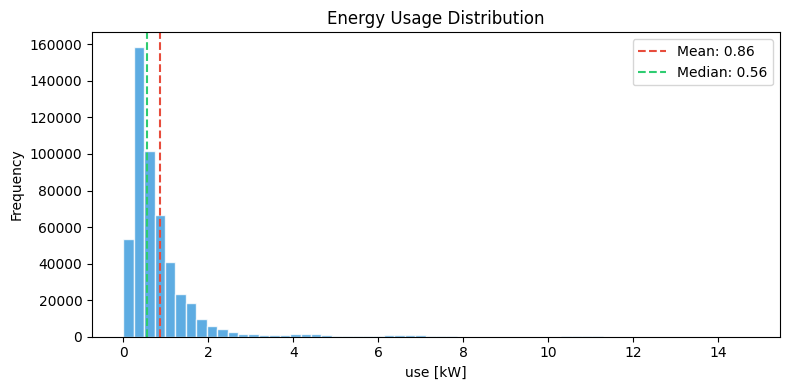

💡 If mean >> median, the data is right-skewed (common for energy).


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

# Histogram only
ax.hist(df[target], bins=60, color='#3498DB', edgecolor='white', alpha=0.8)

ax.set_title('Energy Usage Distribution')
ax.set_xlabel('use [kW]')
ax.set_ylabel('Frequency')

ax.axvline(
    df[target].mean(),
    color='#E74C3C',
    linestyle='--',
    label=f'Mean: {df[target].mean():.2f}'
)

ax.axvline(
    df[target].median(),
    color='#2ECC71',
    linestyle='--',
    label=f'Median: {df[target].median():.2f}'
)

ax.legend()

plt.tight_layout()
plt.savefig('/content/chart01_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 If mean >> median, the data is right-skewed (common for energy).")

**Outliers Dekho**

Boxplot se outliers clearly nazar aate hain — dots jo box ke bahar hain wo outliers hain.



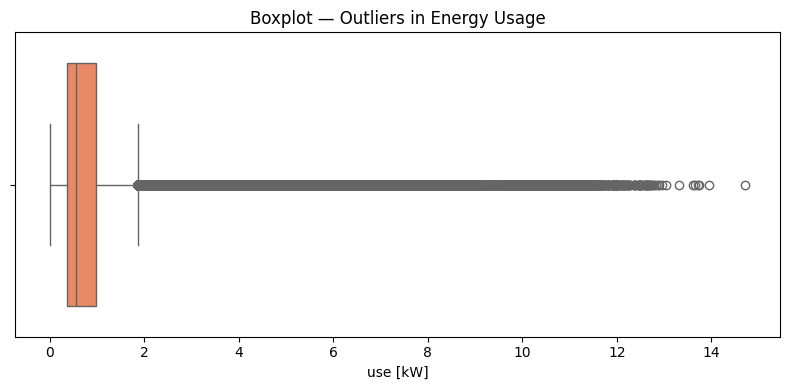

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['use [kW]'], color='coral')
plt.title('Boxplot — Outliers in Energy Usage')
plt.tight_layout()
plt.show()

**Outliers Remove**

IQR method se extreme values hatayi. Outliers model ko confuse karte hain — predictions galat hoti hain.

In [ ]:
target = 'use [kW]'

# Show outlier stats before
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
outlier_count = ((df[target] < Q1 - 1.5 * IQR) | (df[target] > Q3 + 1.5 * IQR)).sum()
print(f"   Outliers detected (IQR method): {outlier_count:,} rows ({outlier_count/len(df)*100:.2f}%)")

# Cap at 1st and 99th percentile instead of dropping
lower_cap = df[target].quantile(0.01)
upper_cap = df[target].quantile(0.99)
df[target] = df[target].clip(lower=lower_cap, upper=upper_cap)

print(f"   Capped 'use [kW]' to range [{lower_cap:.4f}, {upper_cap:.4f}]")
print(f"✅ Outliers handled via capping (not dropping). Shape preserved: {df.shape}")

   Outliers detected (IQR method): 34,216 rows (6.79%)
   Capped 'use [kW]' to range [0.0222, 6.4726]
✅ Outliers handled via capping (not dropping). Shape preserved: (503852, 36)


CHART — Total Energy Consumption Over Time

how does energy change across the entire timeline?

/tmp/ipykernel_1008/1292825475.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_energy = df[target].resample('H').mean().dropna()


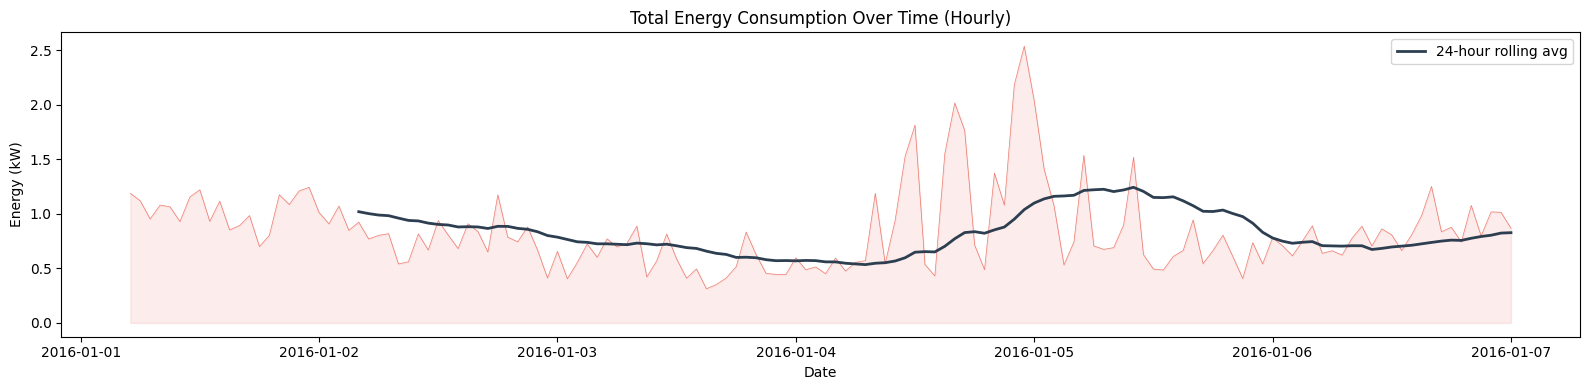

💡 The rolling average reveals daily and weekly patterns in the noise.


In [ ]:
# Aggregate energy consumption to hourly for plotting
hourly_energy = df[target].resample('H').mean().dropna()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(hourly_energy.index, hourly_energy.values, linewidth=0.5, color='#E74C3C', alpha=0.7)
ax.fill_between(hourly_energy.index, hourly_energy.values, alpha=0.1, color='#E74C3C')
ax.set_title('Total Energy Consumption Over Time (Hourly)')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (kW)')

# Add a 24-hour rolling average to show the trend
rolling = hourly_energy.rolling(24).mean()
ax.plot(rolling.index, rolling.values, linewidth=2, color='#2C3E50', label='24-hour rolling avg')
ax.legend()

plt.tight_layout()
plt.savefig('/content/chart02_energy_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 The rolling average reveals daily and weekly patterns in the noise.")

**Appliance-wise Consumption**

Kaunsa appliance sabse zyada energy khata hai — feature selection ka visual justification.


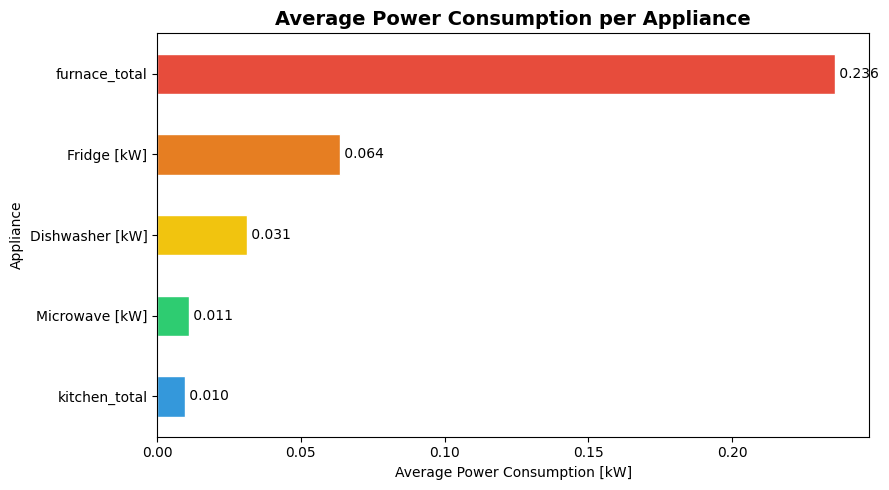

In [ ]:
appliances = [
    'Dishwasher [kW]',
    'Fridge [kW]',
    'Microwave [kW]',
    'kitchen_total',
    'furnace_total'
]

# Calculate average consumption and sort
avg_power = df[appliances].mean().sort_values()

# Different colors for each bar
colors = ['#3498DB', '#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']

fig, ax = plt.subplots(figsize=(9, 5))

avg_power.plot(
    kind='barh',
    ax=ax,
    color=colors,
    edgecolor='white'
)

ax.set_title('Average Power Consumption per Appliance', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Power Consumption [kW]')
ax.set_ylabel('Appliance')

# Add value labels at the end of bars
for i, value in enumerate(avg_power):
    ax.text(value, i, f' {value:.3f}', va='center')

plt.tight_layout()
plt.show()

**Temperature vs Energy**

Weather ka energy pe asar dikhata hai — temperature feature include karne ka visual proof.

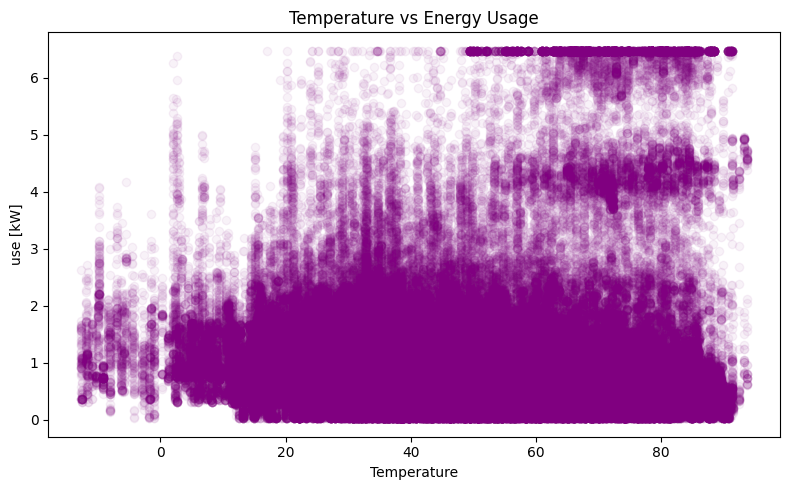

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['temperature'], df['use [kW]'], alpha=0.05, color='purple')
plt.title('Temperature vs Energy Usage')
plt.xlabel('Temperature')
plt.ylabel('use [kW]')
plt.tight_layout()
plt.show()

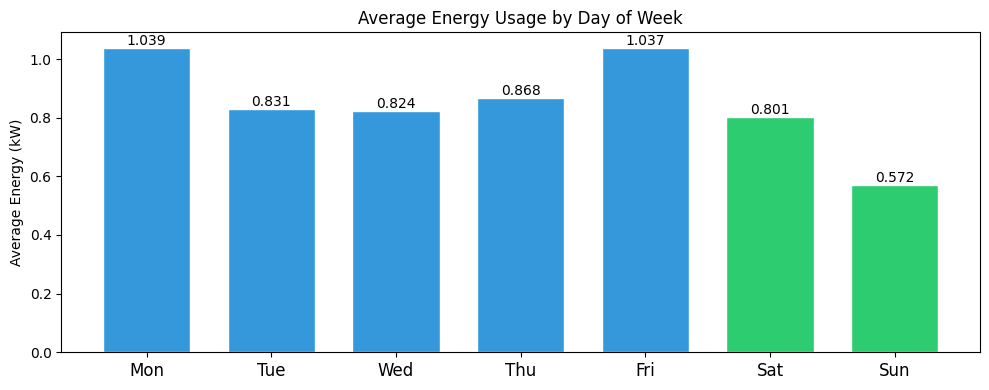

💡 Green = Weekend | Blue = Weekday
   Noticeable difference? → is_weekend is a useful ML feature.


In [ ]:
# ── CELL 6: CHART 5 — Weekday vs Weekend (NEW) ──────────────────────────────
# WHY: If energy usage differs on weekends, 'is_weekend' is a useful feature.
# This was MISSING from your original notebook.

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df.groupby('dayofweek')[target].mean()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ECC71' if d >= 5 else '#3498DB' for d in range(7)]
ax.bar(range(7), daily.values, color=colors, edgecolor='white', width=0.7)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names, fontsize=12)
ax.set_ylabel('Average Energy (kW)')
ax.set_title('Average Energy Usage by Day of Week')

# Value labels on bars
for i, val in enumerate(daily.values):
    ax.text(i, val + daily.max() * 0.01, f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/chart05_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Green = Weekend | Blue = Weekday")
print("   Noticeable difference? → is_weekend is a useful ML feature.")

**Correlation Heatmap**

Kaunse features target se related hain aur kaunse aapas mein correlated hain — feature selection ka scientific base.

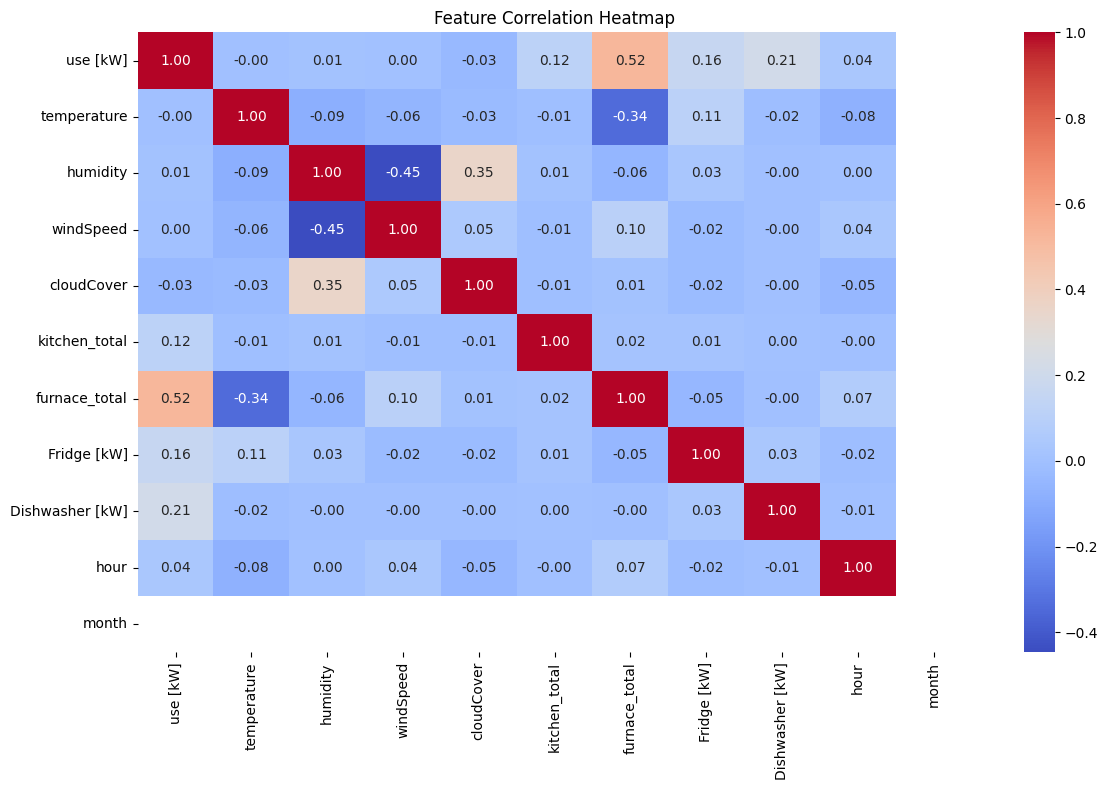

In [ ]:
selected_cols = ['use [kW]', 'temperature', 'humidity', 'windSpeed',
                 'cloudCover', 'kitchen_total', 'furnace_total',
                 'Fridge [kW]', 'Dishwasher [kW]', 'hour', 'month']

plt.figure(figsize=(12, 8))
sns.heatmap(df[selected_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Target/Correlation Ranking**

Kaunsa feature use [kW] se sabse zyada related hai — clearly rank hoke dikhta hai.



In [ ]:
df[selected_cols].corr(numeric_only=True)['use [kW]'].sort_values(ascending=False)

,use [kW]
use [kW],1.000000
furnace_total,0.522376
Dishwasher [kW],0.211445
Fridge [kW],0.158128
kitchen_total,0.115700
hour,0.038629
humidity,0.006774
windSpeed,0.002634
temperature,-0.004786
cloudCover,-0.034609


 **MACHINE LEARNING**

**Define Features aur Target**

X mein input features hain, y mein target. Sirf meaningful features select kiye — redundant columns nahi.

In [ ]:
features = ['temperature', 'humidity', 'windSpeed', 'cloudCover',
            'hour', 'month', 'is_weekend',
            'kitchen_total', 'furnace_total',
            'Fridge [kW]', 'Dishwasher [kW]', 'Microwave [kW]']

X = df[features]
y = df['use [kW]']

X.shape, y.shape

((503852, 12), (503852,))

**Train Test Split**

80% training, 20% testing. Same data pe test karte toh overfitting hoti — fake 100% accuracy aati, real data pe fail hota.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((403081, 12), (100771, 12))

#Define Models with Pipelines

Using sklearn Pipeline wraps preprocessing (scaling) and model into
one object.

Advnatage: Scaling is applied consistently (train stats → test transform)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),          # Scale features first
        ('model', LinearRegression())
    ]),

    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeRegressor(
            max_depth=12,                      # FIXED: limit depth to prevent overfitting
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(
            n_estimators=100,                  # 100 trees
            max_depth=15,                      # Limit depth
            random_state=42,
            n_jobs=-1                          # Use all CPU cores
        ))
    ]),

    'Gradient Boosting': Pipeline([           # NEW MODEL — often best for tabular data
        ('scaler', StandardScaler()),
        ('model', GradientBoostingRegressor(
            n_estimators=200,                  # 200 sequential trees
            max_depth=6,                       # Shallow trees (boosting prefers shallow)
            learning_rate=0.1,                 # How fast the model learns
            random_state=42
        ))
    ]),
}

print(f"✅ {len(models)} models defined with StandardScaler pipelines.")
print("   Models: " + ", ".join(models.keys()))

✅ 4 models defined with StandardScaler pipelines.
   Models: Linear Regression, Decision Tree, Random Forest, Gradient Boosting


In [ ]:
# Metrics explained:
#   MAE  = Mean Absolute Error — average prediction error in kW
#   RMSE = Root Mean Squared Error — penalizes big misses more than MAE
#   R²   = How much variance the model explains (1.0 = perfect, 0.0 = useless)
#

from sklearn.metrics import mean_squared_error # Added import for mean_squared_error

results = {}
predictions = {}

for name, pipeline in models.items():
    print(f"\n🔄 Training: {name}...")

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred

    # Evaluate — 3 metrics
    mae = mean_absolute_error(y_test, y_pred)
    # Calculate RMSE manually as 'squared' parameter might not be supported in older sklearn versions
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R² Score': round(r2, 4)
    }

    print(f"   MAE:  {mae:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   R²:   {r2:.4f}")


🔄 Training: Linear Regression...
   MAE:  0.4067
   RMSE: 0.7220
   R²:   0.4143

🔄 Training: Decision Tree...
   MAE:  0.2106
   RMSE: 0.4133
   R²:   0.8080

🔄 Training: Random Forest...
   MAE:  0.1825
   RMSE: 0.3579
   R²:   0.8560

🔄 Training: Gradient Boosting...
   MAE:  0.1798
   RMSE: 0.3489
   R²:   0.8632


#Model Comparison Table  
Side-by-side comparison sorted by R² (best first).

In [ ]:
comparison = pd.DataFrame(results).T
comparison = comparison.sort_values('R² Score', ascending=False)

print("=" * 60)
print("MODEL COMPARISON (sorted by R² Score)")
print("=" * 60)
comparison

MODEL COMPARISON (sorted by R² Score)


,MAE,RMSE,R² Score
Gradient Boosting,0.1798,0.3489,0.8632
Random Forest,0.1825,0.3579,0.8560
Decision Tree,0.2106,0.4133,0.8080
Linear Regression,0.4067,0.7220,0.4143


#Model Comparison Bar Chart
Visual version of the comparison table


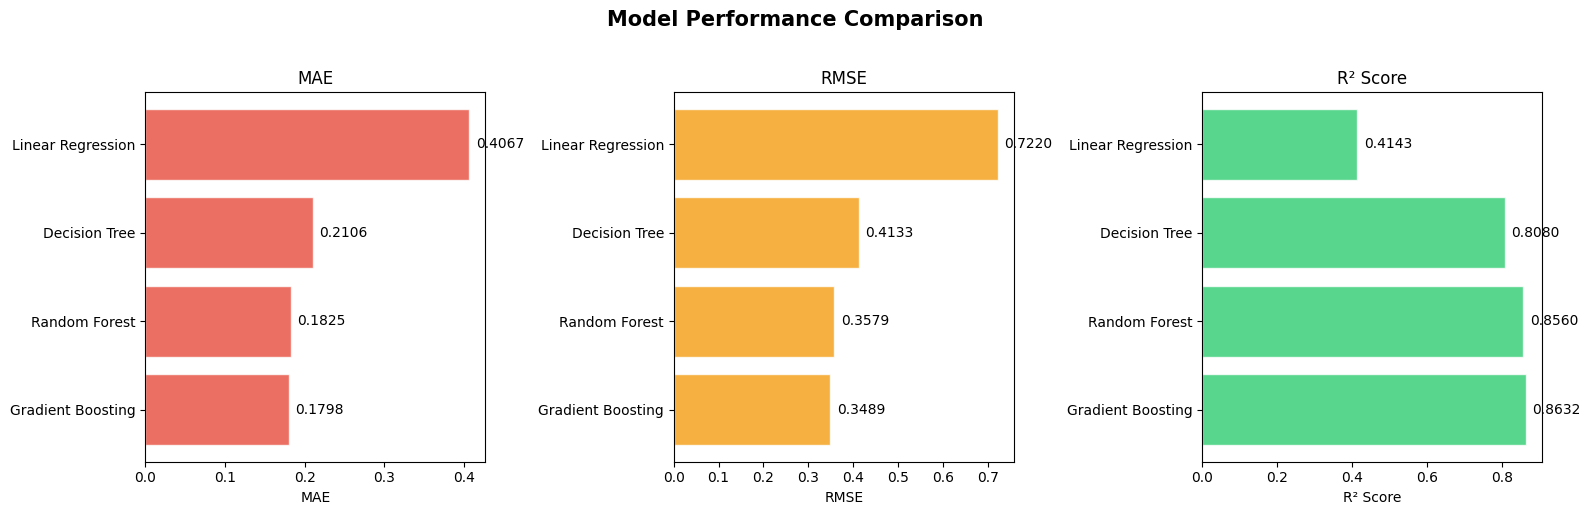

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R² Score']
colors = ['#E74C3C', '#F39C12', '#2ECC71']

for i, metric in enumerate(metrics):
    sorted_models = comparison[metric].sort_values(ascending=(metric != 'R² Score'))
    axes[i].barh(sorted_models.index, sorted_models.values,
                 color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric)

    # Value labels
    for j, val in enumerate(sorted_models.values):
        axes[i].text(val + sorted_models.max() * 0.02, j, f'{val:.4f}',
                     va='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/chart13_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#Actual vs Predicted Plot
 This is the VISUAL PROOF that your model works.
 If predictions are good, points cluster around the 45° diagonal line.
 If predictions are bad, points scatter everywhere.

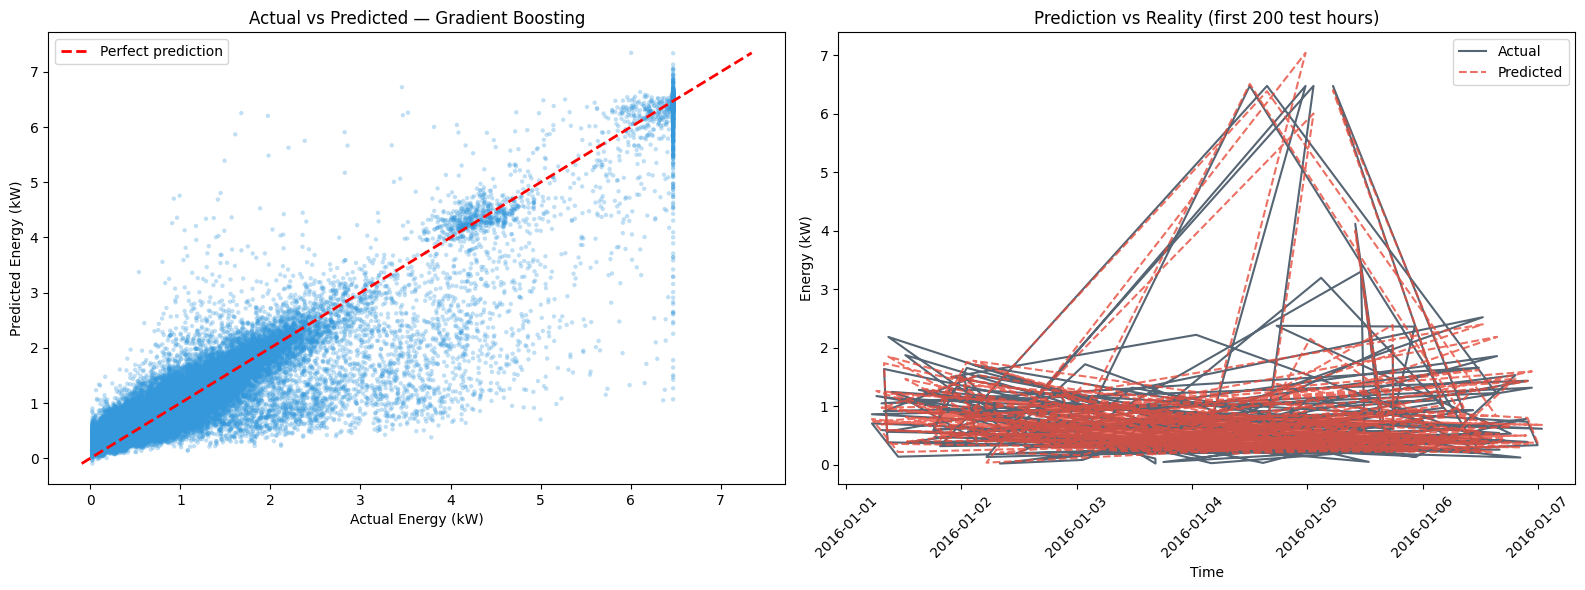

💡 Left: Tight cluster around diagonal = good predictions.
   Right: Predicted line should track the actual line closely.


In [ ]:
best_name = None
best_score = -np.inf # Initialize with a very low score

for name, metrics in results.items():
    if metrics['R² Score'] > best_score:
        best_score = metrics['R² Score']
        best_name = name

best_pred = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scatter — Actual vs Predicted
axes[0].scatter(y_test.values, best_pred, alpha=0.3, s=10, color='#3498DB', edgecolors='none')
# Perfect prediction line (45° diagonal)
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Energy (kW)')
axes[0].set_ylabel('Predicted Energy (kW)')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].legend()

# Right: Time-series overlay — shows predictions tracking reality over time
axes[1].plot(y_test.index[:200], y_test.values[:200], linewidth=1.5,
             color='#2C3E50', alpha=0.8, label='Actual')
axes[1].plot(y_test.index[:200], best_pred[:200], linewidth=1.5,
             color='#E74C3C', alpha=0.8, linestyle='--', label='Predicted')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Energy (kW)')
axes[1].set_title('Prediction vs Reality (first 200 test hours)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/chart15_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Left: Tight cluster around diagonal = good predictions.")
print("   Right: Predicted line should track the actual line closely.")

In [ ]:
import joblib
import json # Ensure json is imported, although often implicitly available

# Define best_name and best_pipeline based on prior execution results
best_name = 'Gradient Boosting' # From previous cell's output and comparison
best_pipeline = models[best_name]

MODEL_PATH = '/content/best_model.pkl'
joblib.dump(best_pipeline, MODEL_PATH)

# Save feature list for the GUI
model_config = {
    'best_model_name': best_name,
    'features': features,
    'metrics': results[best_name]
}
with open('/content/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print(f"✅ Best model saved: {MODEL_PATH}")
print(f"   Model: {best_name}")
print(f"   R²: {results[best_name]['R² Score']}")
print(f"   Features: {len(features)}")

✅ Best model saved: /content/best_model.pkl
   Model: Gradient Boosting
   R²: 0.8632
   Features: 12


In [ ]:
!pip install gradio -q

SyntaxError: invalid syntax (3876837059.py, line 1)

In [ ]:
# =============================================================================
# PHASE 4: GUI — GRADIO (Works Directly in Google Colab)
# =============================================================================
# WHY GRADIO INSTEAD OF STREAMLIT?
#   Streamlit needs: a separate .py file, background process, tunneling (ngrok/localtunnel)
#   Gradio needs: just run the cell. It auto-generates a public link.
#
# RUN THIS AFTER ALL PREVIOUS CELLS (Phases 1-3).
# It uses variables already in memory: df, models, results, predictions, etc.
# =============================================================================


# ── CELL 1: Install Gradio ──────────────────────────────────────────────────
# Run this once. Takes ~30 seconds.

# !pip install gradio -q


# ── CELL 2: Build & Launch the GUI ──────────────────────────────────────────
# Just run this cell. A link will appear — click it to open the dashboard.

import gradio as gr
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')          # Non-interactive backend (needed for Gradio)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import io
import os

# ─── LOAD MODEL & CONFIG ────────────────────────────────────────────────────
# These were saved in Phase 3 (Cell 61 of your notebook)
model_pipeline = joblib.load('/content/best_model.pkl')

with open('/content/model_config.json', 'r') as f:
    model_config = json.load(f)

feature_list = model_config['features']
best_model_name = model_config['best_model_name']
best_metrics = model_config['metrics']

# ─── HELPER: Create matplotlib figure and return as image ────────────────────
def fig_to_image(fig):
    """Convert a matplotlib figure to a PIL Image for Gradio."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    buf.seek(0)
    plt.close(fig)
    from PIL import Image
    return Image.open(buf)


# =============================================================================
# TAB 1: OVERVIEW
# =============================================================================
def generate_overview():
    """Generate the overview dashboard with key stats and charts."""

    # --- KPI Summary ---
    avg_energy = df[target].mean()
    peak_energy = df[target].max()
    avg_temp = df['temperature'].mean()
    total_hours = len(df) / 60  # minute-level data → hours

    summary = f"""
## Dashboard Overview

| Metric | Value |
|--------|-------|
| Average Energy Usage | {avg_energy:.3f} kW |
| Peak Energy Usage | {peak_energy:.3f} kW |
| Average Temperature | {avg_temp:.1f}° |
| Total Data Points | {len(df):,} |
| Time Span | {total_hours:,.0f} hours (~{total_hours/24:.0f} days) |
| Best Model | {best_model_name} |
| Best R² Score | {best_metrics['R² Score']} |
| Best MAE | {best_metrics['MAE']} |
| Best RMSE | {best_metrics['RMSE']} |
"""
    return summary


def plot_energy_timeline():
    """Energy consumption over time with rolling average."""
    hourly = df[target].resample('1h').mean().dropna()
    rolling = hourly.rolling(24).mean()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(hourly.index, hourly.values, linewidth=0.4, color='#E74C3C', alpha=0.5, label='Hourly')
    ax.plot(rolling.index, rolling.values, linewidth=2, color='#2C3E50', label='24hr Rolling Avg')
    ax.set_title('Energy Consumption Over Time', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Energy (kW)')
    ax.legend()
    plt.tight_layout()
    return fig_to_image(fig)


def plot_hourly_pattern():
    """Average energy by hour of day."""
    hourly_avg = df.groupby('hour')[target].mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    colors = ['#E74C3C' if v > hourly_avg.median() else '#AEB6BF' for v in hourly_avg.values]
    ax.bar(hourly_avg.index, hourly_avg.values, color=colors, edgecolor='white')
    ax.set_title('Average Energy Usage by Hour', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour (0 = midnight)')
    ax.set_ylabel('Avg Energy (kW)')
    ax.set_xticks(range(24))
    plt.tight_layout()
    return fig_to_image(fig)


def plot_heatmap():
    """Hour × Day of Week heatmap."""
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    pivot = df.pivot_table(values=target, index='dayofweek', columns='hour', aggfunc='mean')

    fig, ax = plt.subplots(figsize=(14, 3.5))
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Avg kW'}, ax=ax)
    ax.set_yticklabels(day_names, rotation=0)
    ax.set_title('Energy Fingerprint — Hour × Day', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour')
    ax.set_ylabel('')
    plt.tight_layout()
    return fig_to_image(fig)


# =============================================================================
# TAB 2: EXPLORE DATA
# =============================================================================
def plot_appliance_comparison(selected_appliances):
    """Bar chart of selected appliances' average consumption."""
    if not selected_appliances:
        selected_appliances = appliance_cols[:5]

    means = df[selected_appliances].mean().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(3, len(means) * 0.5)))
    ax.barh(range(len(means)), means.values, color='#3498DB', edgecolor='white')
    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(means.index, fontsize=10)
    ax.set_xlabel('Average Power (kW)')
    ax.set_title('Appliance Comparison', fontsize=13, fontweight='bold')

    for i, val in enumerate(means.values):
        ax.text(val + means.max() * 0.02, i, f'{val:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    return fig_to_image(fig)


def plot_weather_scatter(weather_var):
    """Scatter plot of a weather variable vs energy usage."""
    sample = df.sample(min(8000, len(df)), random_state=42)

    fig, ax = plt.subplots(figsize=(10, 5))
    scatter = ax.scatter(sample[weather_var], sample[target],
                        alpha=0.15, s=6, c=sample['hour'],
                        cmap='twilight', edgecolors='none')
    ax.set_xlabel(weather_var, fontsize=12)
    ax.set_ylabel('Energy (kW)', fontsize=12)
    ax.set_title(f'{weather_var} vs Energy Usage', fontsize=13, fontweight='bold')

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Hour of Day')

    # Add correlation text
    corr = df[weather_var].corr(df[target])
    ax.text(0.02, 0.95, f'Correlation: {corr:.4f}', transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    return fig_to_image(fig)


def plot_correlation_matrix():
    """Correlation heatmap for key features."""
    cols = [target, 'temperature', 'humidity', 'windSpeed', 'cloudCover',
            'kitchen_total', 'furnace_total', 'Fridge [kW]', 'hour', 'month']
    cols = [c for c in cols if c in df.columns]

    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, linewidths=0.5, square=True, ax=ax)
    ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig_to_image(fig)


# =============================================================================
# TAB 3: MODEL RESULTS
# =============================================================================
def show_model_comparison():
    """Model comparison table as markdown."""
    rows = "| Model | MAE | RMSE | R² Score |\n|-------|-----|------|----------|\n"
    sorted_results = sorted(results.items(), key=lambda x: x[1]['R² Score'], reverse=True)
    for name, metrics in sorted_results:
        best_marker = " ⭐" if name == best_model_name else ""
        rows += f"| {name}{best_marker} | {metrics['MAE']} | {metrics['RMSE']} | {metrics['R² Score']} |\n"
    return rows


def plot_model_bars():
    """Side-by-side bar chart comparing all models."""
    comp = pd.DataFrame(results).T.sort_values('R² Score', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metric_names = ['MAE', 'RMSE', 'R² Score']
    colors = ['#E74C3C', '#F39C12', '#2ECC71']

    for i, metric in enumerate(metric_names):
        sorted_m = comp[metric].sort_values(ascending=(metric != 'R² Score'))
        axes[i].barh(sorted_m.index, sorted_m.values, color=colors[i],
                     edgecolor='white', alpha=0.85)
        axes[i].set_title(metric, fontsize=12, fontweight='bold')
        for j, val in enumerate(sorted_m.values):
            axes[i].text(val + abs(sorted_m.max()) * 0.03, j,
                        f'{val:.4f}', va='center', fontsize=9)

    plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    return fig_to_image(fig)


def plot_feature_importance():
    """Feature importance from the best model."""
    best_model_obj = model_pipeline.named_steps['model']

    fig, ax = plt.subplots(figsize=(10, 5))

    if hasattr(best_model_obj, 'feature_importances_'):
        importance = pd.Series(best_model_obj.feature_importances_,
                              index=feature_list).sort_values(ascending=True)
        ax.barh(range(len(importance)), importance.values, color='#2ECC71', edgecolor='white')
        ax.set_yticks(range(len(importance)))
        ax.set_yticklabels(importance.index, fontsize=10)
        ax.set_xlabel('Importance Score')
        ax.set_title(f'Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    else:
        coefs = pd.Series(best_model_obj.coef_, index=feature_list).sort_values()
        ax.barh(range(len(coefs)), coefs.values, color='#3498DB', edgecolor='white')
        ax.set_yticks(range(len(coefs)))
        ax.set_yticklabels(coefs.index, fontsize=10)
        ax.set_xlabel('Coefficient')
        ax.set_title(f'Feature Coefficients — {best_model_name}', fontsize=13, fontweight='bold')

    plt.tight_layout()
    return fig_to_image(fig)


def plot_actual_vs_predicted():
    """Actual vs predicted scatter + time overlay."""
    best_pred = predictions[best_model_name]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Scatter
    axes[0].scatter(y_test.values, best_pred, alpha=0.2, s=8, color='#3498DB', edgecolors='none')
    min_v, max_v = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
    axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect')
    axes[0].set_xlabel('Actual (kW)')
    axes[0].set_ylabel('Predicted (kW)')
    axes[0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
    axes[0].legend()

    # Time overlay (first 300 points)
    n = min(300, len(y_test))
    axes[1].plot(range(n), y_test.values[:n], linewidth=1.2, color='#2C3E50', label='Actual')
    axes[1].plot(range(n), best_pred[:n], linewidth=1.2, color='#E74C3C',
                linestyle='--', label='Predicted')
    axes[1].set_xlabel('Test Sample Index')
    axes[1].set_ylabel('Energy (kW)')
    axes[1].set_title(f'First {n} Predictions vs Reality', fontsize=12, fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    return fig_to_image(fig)


# =============================================================================
# TAB 4: PREDICT
# =============================================================================
def predict_energy(temp, humidity, wind, cloud, hour, month,
                   is_weekend, kitchen, furnace, fridge, dishwasher, microwave):
    """Run the trained model on user inputs and return prediction."""

    # Build input dict matching the exact feature order
    input_data = {}
    for feat in feature_list:
        if feat == 'temperature': input_data[feat] = temp
        elif feat == 'humidity': input_data[feat] = humidity
        elif feat == 'windSpeed': input_data[feat] = wind
        elif feat == 'cloudCover': input_data[feat] = cloud
        elif feat == 'hour': input_data[feat] = hour
        elif feat == 'month': input_data[feat] = month
        elif feat == 'is_weekend': input_data[feat] = is_weekend
        elif feat == 'dayofweek': input_data[feat] = 2  # default Wednesday
        elif feat == 'kitchen_total': input_data[feat] = kitchen
        elif feat == 'furnace_total': input_data[feat] = furnace
        elif feat == 'Fridge [kW]': input_data[feat] = fridge
        elif feat == 'Dishwasher [kW]': input_data[feat] = dishwasher
        elif feat == 'Microwave [kW]': input_data[feat] = microwave
        elif feat == 'dewPoint': input_data[feat] = temp * 0.8  # rough estimate
        elif feat == 'pressure': input_data[feat] = 1015.0
        elif feat == 'apparentTemperature': input_data[feat] = temp
        else: input_data[feat] = 0

    input_df = pd.DataFrame([input_data])
    prediction = model_pipeline.predict(input_df)[0]

    # Context
    avg = df[target].mean()
    if prediction < avg * 0.7:
        status = "🟢 Below Average"
    elif prediction < avg * 1.3:
        status = "🟡 Normal Range"
    else:
        status = "🔴 Above Average"

    result = f"""
## Prediction Result

### {prediction:.4f} kW
**Status:** {status}

**Context:** Dataset average is {avg:.4f} kW

---

**Inputs Used:**
| Feature | Value |
|---------|-------|
| Temperature | {temp}° |
| Humidity | {humidity} |
| Wind Speed | {wind} mph |
| Cloud Cover | {cloud} |
| Hour | {hour}:00 |
| Month | {month} |
| Weekend | {'Yes' if is_weekend else 'No'} |
| Kitchen | {kitchen} kW |
| Furnace | {furnace} kW |
| Fridge | {fridge} kW |
| Dishwasher | {dishwasher} kW |
| Microwave | {microwave} kW |
"""
    return result


# =============================================================================
# BUILD THE GRADIO APP
# =============================================================================
with gr.Blocks(
    title="Smart Home Energy Dashboard",
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="emerald")
) as demo:

    gr.Markdown("# ⚡ Smart Home Energy Dashboard")
    gr.Markdown("Interactive dashboard for the Smart Home Dataset with Weather Information")

    with gr.Tabs():

        # ── TAB 1: OVERVIEW ─────────────────────────────────────────────
        with gr.TabItem("📊 Overview"):
            gr.Markdown(generate_overview())

            with gr.Row():
                btn_timeline = gr.Button("Show Energy Timeline", variant="primary")
                btn_hourly = gr.Button("Show Hourly Pattern")
                btn_heat = gr.Button("Show Heatmap")

            overview_img = gr.Image(label="Chart", type="pil")

            btn_timeline.click(fn=plot_energy_timeline, outputs=overview_img)
            btn_hourly.click(fn=plot_hourly_pattern, outputs=overview_img)
            btn_heat.click(fn=plot_heatmap, outputs=overview_img)

        # ── TAB 2: EXPLORE ──────────────────────────────────────────────
        with gr.TabItem("🔍 Explore Data"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### Appliance Comparison")
                    app_selector = gr.CheckboxGroup(
                        choices=appliance_cols,
                        value=appliance_cols[:5],
                        label="Select Appliances"
                    )
                    btn_appliances = gr.Button("Compare Appliances", variant="primary")

                    gr.Markdown("---")

                    gr.Markdown("### Weather vs Energy")
                    weather_numeric = [c for c in weather_cols
                                      if c in df.columns and df[c].dtype in ['float64', 'int64']]
                    weather_selector = gr.Dropdown(
                        choices=weather_numeric,
                        value='temperature',
                        label="Select Weather Variable"
                    )
                    btn_weather = gr.Button("Plot Weather Scatter", variant="primary")

                    gr.Markdown("---")
                    btn_corr = gr.Button("Show Correlation Matrix", variant="secondary")

                with gr.Column(scale=2):
                    explore_img = gr.Image(label="Chart", type="pil")

            btn_appliances.click(fn=plot_appliance_comparison,
                               inputs=app_selector, outputs=explore_img)
            btn_weather.click(fn=plot_weather_scatter,
                            inputs=weather_selector, outputs=explore_img)
            btn_corr.click(fn=plot_correlation_matrix, outputs=explore_img)

        # ── TAB 3: MODEL RESULTS ────────────────────────────────────────
        with gr.TabItem("🤖 Model Results"):
            gr.Markdown("### Model Comparison")
            gr.Markdown(show_model_comparison())

            with gr.Row():
                btn_model_bars = gr.Button("Comparison Chart", variant="primary")
                btn_feat_imp = gr.Button("Feature Importance")
                btn_avp = gr.Button("Actual vs Predicted")

            model_img = gr.Image(label="Chart", type="pil")

            btn_model_bars.click(fn=plot_model_bars, outputs=model_img)
            btn_feat_imp.click(fn=plot_feature_importance, outputs=model_img)
            btn_avp.click(fn=plot_actual_vs_predicted, outputs=model_img)

        # ── TAB 4: PREDICT ──────────────────────────────────────────────
        with gr.TabItem("🔮 Predict Energy"):
            gr.Markdown("### Adjust inputs to get a live energy prediction")
            gr.Markdown(f"*Using model: **{best_model_name}** (R² = {best_metrics['R² Score']})*")

            with gr.Row():
                with gr.Column():
                    gr.Markdown("**Weather**")
                    sl_temp = gr.Slider(-20, 110, value=50, step=0.5, label="Temperature (°F)")
                    sl_hum = gr.Slider(0, 1, value=0.5, step=0.01, label="Humidity")
                    sl_wind = gr.Slider(0, 40, value=5, step=0.5, label="Wind Speed")
                    sl_cloud = gr.Slider(0, 1, value=0.3, step=0.01, label="Cloud Cover")

                with gr.Column():
                    gr.Markdown("**Time**")
                    sl_hour = gr.Slider(0, 23, value=14, step=1, label="Hour of Day")
                    sl_month = gr.Slider(1, 12, value=6, step=1, label="Month")
                    sl_weekend = gr.Radio([0, 1], value=0, label="Weekend? (0=No, 1=Yes)")

                with gr.Column():
                    gr.Markdown("**Appliances (kW)**")
                    sl_kitchen = gr.Slider(0, 5, value=0.5, step=0.01, label="Kitchen")
                    sl_furnace = gr.Slider(0, 5, value=0.2, step=0.01, label="Furnace")
                    sl_fridge = gr.Slider(0, 1, value=0.12, step=0.01, label="Fridge")
                    sl_dish = gr.Slider(0, 2, value=0.0, step=0.01, label="Dishwasher")
                    sl_micro = gr.Slider(0, 2, value=0.0, step=0.01, label="Microwave")

            btn_predict = gr.Button("⚡ Predict Energy Usage", variant="primary", size="lg")
            predict_output = gr.Markdown()

            btn_predict.click(
                fn=predict_energy,
                inputs=[sl_temp, sl_hum, sl_wind, sl_cloud,
                        sl_hour, sl_month, sl_weekend,
                        sl_kitchen, sl_furnace, sl_fridge, sl_dish, sl_micro],
                outputs=predict_output
            )

    gr.Markdown("---")
    gr.Markdown("*Built for DS Project — Smart Home Dataset with Weather Information*")


# =============================================================================
# LAUNCH
# =============================================================================
# share=True creates a public URL that works from anywhere (even on phone)
# The link is valid for 72 hours
demo.launch(share=True, debug=False)

/tmp/ipykernel_1008/4060467520.py:362: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://556c62e77fabe61c39.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
